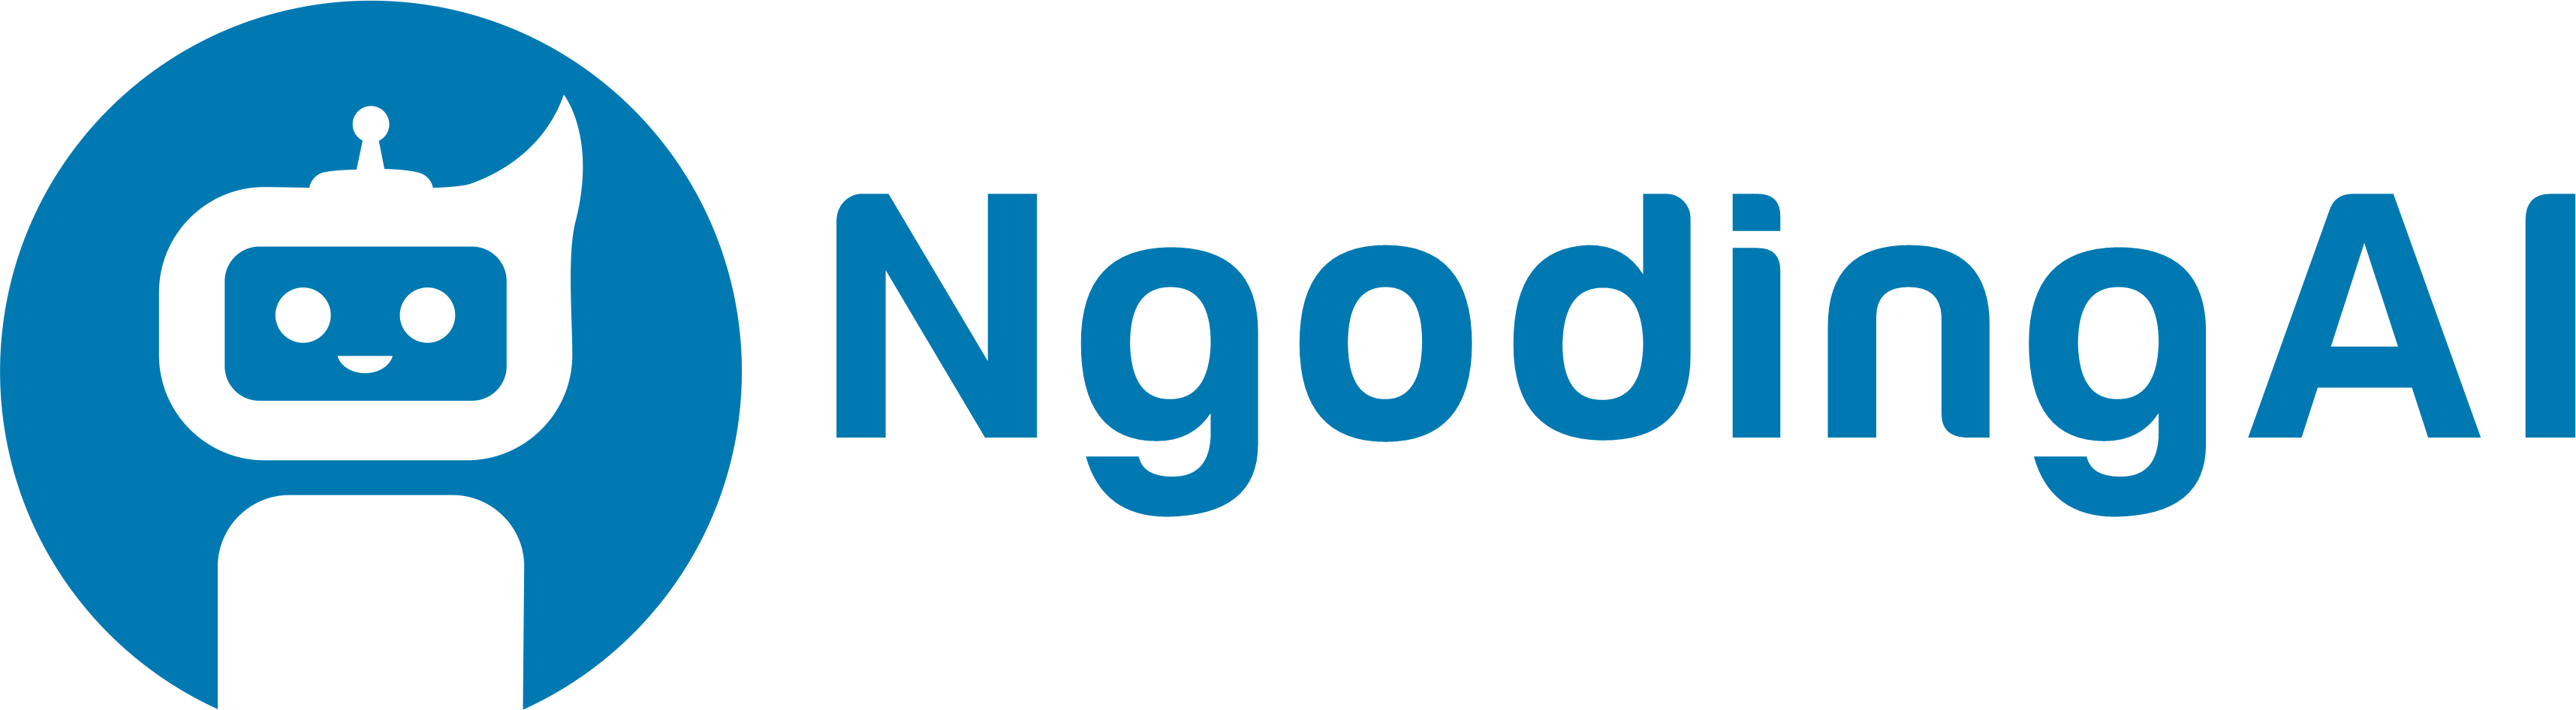

# Model Development: Deteksi Spam SMS

Notebook ini memandu proses pengembangan model ML dari awal hingga siap deploy.

Kita akan membangun model klasifikasi teks untuk mendeteksi SMS **normal**, **spam**, dan **promo** menggunakan pipeline scikit-learn.

## 1. Persiapan

Pastikan semua library yang dibutuhkan sudah terinstall. Kita cek versi masing-masing library terlebih dahulu.

In [ ]:
# Cek versi library yang dibutuhkan
import IPython
print('IPython:', IPython.__version__)

import numpy as np
print('numpy:', np.__version__)

import pandas as pd
print('pandas:', pd.__version__)

import sklearn
print('scikit-learn:', sklearn.__version__)

import matplotlib
print('matplotlib:', matplotlib.__version__)

## 2. Load Data

Dataset yang kita gunakan berisi SMS dalam bahasa Indonesia yang sudah dilabeli:
- **0** = normal
- **1** = spam
- **2** = promo

Baca file CSV dan rename kolom agar lebih mudah dipahami.

In [ ]:
# Load dataset SMS spam
import pandas as pd

df = pd.read_csv('../referensi/dataset_sms_spam _v1.csv')

# Rename kolom agar lebih deskriptif
df.columns = ['sms', 'kategori']

Lihat ukuran dataset dan beberapa baris pertama.

In [ ]:
# Lihat ukuran dataset
print('Shape:', df.shape)

In [ ]:
# Lihat 5 baris pertama
df.head()

Cek informasi tipe data dan missing values.

In [ ]:
# Info dataset
df.info()

Lihat distribusi label untuk memahami keseimbangan kelas.

In [ ]:
# Distribusi label
# 0 = normal, 1 = spam, 2 = promo
df.kategori.value_counts()

## 3. Eksplorasi Data

Sebelum membuat model, kita perlu memahami data lebih dalam. Mari lihat contoh teks dari setiap kategori.

Tampilkan contoh SMS untuk setiap kategori.

In [ ]:
# Contoh teks per kategori
label_map = {0: 'normal', 1: 'spam', 2: 'promo'}

for label, nama in label_map.items():
    contoh = df[df.kategori == label].sms.iloc[0]
    print(f'[{nama}] {contoh[:100]}...')
    print()

Analisis panjang teks (jumlah karakter) per kategori.

In [ ]:
# Distribusi panjang teks
import matplotlib.pyplot as plt

df['panjang_teks'] = df.sms.str.len()

fig, ax = plt.subplots(figsize=(8, 4))
for label, nama in label_map.items():
    subset = df[df.kategori == label]
    ax.hist(subset.panjang_teks, bins=30, alpha=0.6, label=nama)

ax.set_xlabel('Panjang Teks (karakter)')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Panjang Teks per Kategori')
ax.legend()
plt.tight_layout()
plt.show()

Analisis jumlah kata per SMS.

In [ ]:
# Distribusi jumlah kata
df['jumlah_kata'] = df.sms.str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 4))
for label, nama in label_map.items():
    subset = df[df.kategori == label]
    ax.hist(subset.jumlah_kata, bins=30, alpha=0.6, label=nama)

ax.set_xlabel('Jumlah Kata')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Jumlah Kata per Kategori')
ax.legend()
plt.tight_layout()
plt.show()

Visualisasi distribusi kelas dalam bentuk bar chart.

In [ ]:
# Bar chart distribusi kelas (Google colors)
colors = ['#34a853', '#ea4335', '#fbbc04']  # green, red, yellow
label_names = ['normal', 'spam', 'promo']
counts = [len(df[df.kategori == i]) for i in range(3)]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(label_names, counts, color=colors, edgecolor='white', linewidth=1.2)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Jumlah SMS')
ax.set_title('Distribusi Kelas')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Preprocessing & Pipeline

Untuk mengubah teks menjadi fitur numerik, kita menggunakan **TF-IDF (Term Frequency - Inverse Document Frequency)**.

TF-IDF mengukur seberapa penting sebuah kata dalam suatu dokumen relatif terhadap seluruh koleksi dokumen. Kata yang sering muncul di satu dokumen tapi jarang di dokumen lain akan mendapat skor tinggi.

Mari lihat contoh sederhana TF-IDF dengan corpus kecil.

In [ ]:
# Contoh sederhana TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

corpus_contoh = [
    'saya suka belajar python',
    'python bagus untuk data science',
    'saya suka data science',
]

tfidf_contoh = TfidfVectorizer()
matriks = tfidf_contoh.fit_transform(corpus_contoh)

# Tampilkan sebagai DataFrame
pd.DataFrame(
    matriks.toarray(),
    columns=tfidf_contoh.get_feature_names_out(),
    index=['doc1', 'doc2', 'doc3']
).round(2)

Sekarang kita split data menjadi training (75%) dan testing (25%).

In [ ]:
# Split data training dan testing
from sklearn.model_selection import train_test_split

X = df['sms'].astype(str)
y = df['kategori']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'Training: {len(X_train)} sampel')
print(f'Testing:  {len(X_test)} sampel')

Buat pipeline yang menggabungkan TF-IDF vectorizer dan model LinearSVC.

`make_pipeline` memudahkan kita menggabungkan beberapa langkah preprocessing dan model menjadi satu objek. Saat kita panggil `fit()`, semua langkah dijalankan berurutan.

In [ ]:
# Buat pipeline: TfidfVectorizer + LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

pipeline = make_pipeline(
    TfidfVectorizer(
        max_features=8000,
        ngram_range=(1, 2),
        sublinear_tf=True,
    ),
    LinearSVC(
        dual='auto',
        max_iter=2000,
    ),
)

print(pipeline)

`make_pipeline` secara otomatis memberi nama setiap step berdasarkan nama class-nya. Ini memudahkan kita mengakses komponen pipeline nanti.

## 5. Training

Saatnya melatih model! Kita gunakan `%%time` untuk mengukur waktu training.

In [ ]:
%%time
# Latih pipeline dengan data training
pipeline.fit(X_train, y_train)

## 6. Evaluasi Model

Setelah model dilatih, kita evaluasi performanya menggunakan data testing. Kita akan melihat beberapa metrik penting.

Hitung akurasi model pada data testing.

In [ ]:
# Hitung akurasi
from sklearn.metrics import accuracy_score

y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Akurasi: {accuracy:.4f} ({accuracy*100:.2f}%)')

Classification report menampilkan metrik detail per kelas:
- **Precision**: dari semua prediksi positif, berapa yang benar?
- **Recall**: dari semua data positif, berapa yang berhasil diprediksi?
- **F1-score**: rata-rata harmonis precision dan recall

In [ ]:
# Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['normal', 'spam', 'promo']))

Confusion matrix menunjukkan detail prediksi benar dan salah per kelas. Kita tampilkan sebagai heatmap agar lebih mudah dibaca.

In [ ]:
# Confusion matrix heatmap
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['normal', 'spam', 'promo'],
    cmap='Blues',
    ax=ax,
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

Visualisasi F1-score per kelas dalam bentuk bar chart.

In [ ]:
# F1-score per class bar chart
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

f1_scores = [
    report.get('0', {}).get('f1-score', 0.0),
    report.get('1', {}).get('f1-score', 0.0),
    report.get('2', {}).get('f1-score', 0.0),
]
label_names = ['normal', 'spam', 'promo']
colors = ['#34a853', '#ea4335', '#fbbc04']  # green, red, yellow

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(label_names, f1_scores, color=colors, edgecolor='white', linewidth=1.2)

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score per Class')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Perbandingan distribusi kelas: Actual vs Predicted (pie chart).

In [ ]:
# Class distribution pie chart: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ['#34a853', '#ea4335', '#fbbc04']
label_names_pie = ['normal', 'spam', 'promo']

# Actual distribution
actual_counts = y_test.value_counts().sort_index()
actual_labels = [label_names_pie[i] for i in actual_counts.index]
axes[0].pie(actual_counts, labels=actual_labels, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Actual (Test Set)')

# Predicted distribution
import pandas as pd
pred_series = pd.Series(y_pred)
pred_counts = pred_series.value_counts().sort_index()
pred_labels = [label_names_pie[i] for i in pred_counts.index]
axes[1].pie(pred_counts, labels=pred_labels, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Predicted')

plt.suptitle('Class Distribution: Actual vs Predicted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Sanity Check

Sebelum menyimpan model, kita lakukan sanity check — prediksi beberapa sampel dari test set dan bandingkan dengan label sebenarnya.

Prediksi 5 sampel dari test set dan tampilkan dalam tabel.

In [ ]:
# Sanity check: prediksi 5 sampel dari test set
label_map = {0: 'normal', 1: 'spam', 2: 'promo'}
n_samples = 5

samples_X = X_test.values[:n_samples]
samples_y = y_test.values[:n_samples]
samples_pred = pipeline.predict(samples_X)

# Buat tabel hasil
results = []
for text, expected, predicted in zip(samples_X, samples_y, samples_pred):
    exp_name = label_map[expected]
    pred_name = label_map[predicted]
    match = '✅' if exp_name == pred_name else '❌'
    truncated = text[:80] + '..' if len(text) > 80 else text
    results.append({
        'Expected': exp_name,
        'Predicted': pred_name,
        'Match': match,
        'Text': truncated,
    })

pd.DataFrame(results)

Coba prediksi dengan SMS baru yang kita tulis sendiri.

In [ ]:
# Prediksi SMS baru (custom)
sms_baru = [
    'Halo, apa kabar? Besok jadi ketemu kan?',
    'SELAMAT! Anda memenangkan hadiah 100 JUTA! Klik link ini segera!',
    'Promo spesial hari ini! Diskon 50% untuk semua paket internet.',
    'Mas, tolong beliin makan siang ya. Nasi goreng aja.',
    'Dapatkan pinjaman tanpa jaminan hingga 500jt. Hubungi 0812xxxx',
]

prediksi = pipeline.predict(sms_baru)

for sms, pred in zip(sms_baru, prediksi):
    print(f'[{label_map[pred]:>6}] {sms}')

## 8. Simpan Model

Setelah model siap, kita simpan ke file menggunakan `joblib`. Joblib lebih efisien daripada pickle untuk objek yang mengandung array numpy besar.

Serialisasi model memungkinkan kita menggunakan model di aplikasi lain (misalnya API backend) tanpa harus melatih ulang.

In [ ]:
# Simpan model dengan joblib
import joblib

model_path = 'model_spam_sms.pkl'
joblib.dump(pipeline, model_path)

print(f'Model disimpan ke: {model_path}')

Cek ukuran file model yang tersimpan.

In [ ]:
# Cek ukuran file model
import os

size_bytes = os.path.getsize(model_path)
size_kb = size_bytes / 1024
size_mb = size_kb / 1024

print(f'Ukuran file: {size_bytes:,} bytes ({size_kb:.1f} KB / {size_mb:.2f} MB)')

## 9. Load & Verifikasi Model

Untuk memastikan model tersimpan dengan benar, kita load kembali dari file dan verifikasi hasilnya sama dengan model asli.

Load model dari file.

In [ ]:
# Load model dari file
model_loaded = joblib.load(model_path)

print(f'Model berhasil di-load: {type(model_loaded)}')

Prediksi dengan model yang di-load dan bandingkan dengan model asli.

In [ ]:
# Prediksi dengan model yang di-load
y_pred_loaded = model_loaded.predict(X_test)

# Verifikasi hasil sama dengan model asli
import numpy as np
sama = np.array_equal(y_pred, y_pred_loaded)

print(f'Hasil prediksi identik: {sama}')
print(f'Akurasi model loaded: {accuracy_score(y_test, y_pred_loaded):.4f}')

Coba prediksi SMS baru dengan model yang di-load.

In [ ]:
# Prediksi SMS baru dengan model loaded
sms_tes = ['Halo, kapan kita bisa ketemu?']
hasil = model_loaded.predict(sms_tes)

print(f'SMS: {sms_tes[0]}')
print(f'Prediksi: {label_map[hasil[0]]}')

## 10. Ringkasan

Dalam notebook ini, kita telah melakukan:

1. **Load & eksplorasi data** — memahami distribusi SMS normal, spam, dan promo
2. **Preprocessing** — menggunakan TF-IDF untuk mengubah teks menjadi fitur numerik
3. **Pipeline** — menggabungkan TfidfVectorizer + LinearSVC dalam satu pipeline
4. **Training & evaluasi** — melatih model dan mengukur performa dengan berbagai metrik
5. **Sanity check** — memverifikasi prediksi model pada sampel nyata
6. **Simpan & load model** — menyimpan model ke file dan memverifikasi konsistensi

### Langkah Selanjutnya

Model ini siap untuk di-deploy ke production melalui CI/CD pipeline:
- Integrasi dengan **FastAPI** backend untuk serving prediksi
- **Automated training & evaluation** via GitHub Actions
- **PR report** otomatis dengan metrik perbandingan model

Selamat! Anda telah menyelesaikan proses model development end-to-end. 🎉